**Link al repositorio de GitHub:** [https://github.com/vgcarlol/Aprendizaje-Por-Refuerzo](https://github.com/vgcarlol/Aprendizaje-Por-Refuerzo)

# CC3104 - Aprendizaje por Refuerzo
## Laboratorio 4 - Entrega Total

---
### Task 1: Diseño formal del MDP

#### 1. Espacio de estados y acciones (Gymnasium)
*   **Espacio de Estados (observation_space):** Utilizaremos `gymnasium.spaces.Discrete(64)` para representar la cuadrícula de 8x8. 
    *   *Justificación:* Cada estado se mapea directamente a un entero único del 0 al 63 calculando `fila * 8 + columna`. `Discrete` es el espacio más apropiado porque las posiciones son finitas, mutuamente excluyentes, y el agente solo puede ocupar una celda exacta a la vez. Usar `Box` (continuo) implicaría coordenadas continuas, lo cual no aplica a la abstracción de almacén dividida por cuadrantes que usamos.
*   **Espacio de Acciones (action_space):** Utilizaremos `gymnasium.spaces.Discrete(4)`.
    *   *Justificación:* Las acciones son moverse a las 4 direcciones cardinales (0: Arriba, 1: Derecha, 2: Abajo, 3: Izquierda). De nuevo, `Discrete` es la estructura natural para esto.

#### 2. Función de Recompensa
Nuestra función cuenta con tres componentes:
*   **Recompensa por entrega exitosa:** $+100$ al alcanzar la celda de destino.
*   **Penalización por zona de congestión:** $-100$ al pisar zonas de alto tráfico de carretillas, y además el robot es regresado a la posición inicial por seguridad.
*   **Penalización por paso:** $-1$ por cada movimiento en una celda vacía.
*   **Justificación de magnitudes:** La recompensa de $+100$ es el incentivo principal. El paso de $-1$ obliga a buscar la ruta más corta posible. La penalización de $-100$ por congestión es masivamente negativa porque en el almacén un accidente o atasco de un robot en una zona de alta operación humana cuesta muchísimo tiempo y dinero.
*   **Comportamiento indeseable por mala ponderación:** Si la congestión fuera penalizada solo con un $-2$, un algoritmo agresivo podría decidir cruzar a través del tráfico constantemente (recibiendo $-2$ por paso) si resulta ser una ruta un poco más corta, poniendo en riesgo a los trabajadores.

#### 3. Condición de terminación del episodio
*   **¿Cuándo termina?** El episodio termina cuando el agente alcanza la meta (punto de entrega) o cuando se agota un límite máximo de pasos.
*   **¿Es apropiado un límite máximo?** Sí, es absolutamente **crítico**. Si un robot (especialmente al inicio del entrenamiento bajo una política puramente aleatoria) se queda atascado detrás de un obstáculo fijo y no hay límite de pasos, el episodio se ejecutaría infinitamente (bucle infinito), agotando la memoria y deteniendo el proceso de entrenamiento. Proponemos un límite de `max_steps = 200`.

#### 4. Diseño del mapa 8x8
Para observar la diferencia crítica entre Q-Learning y SARSA (un escenario de tipo *Cliff Walking*):
*   **Inicio:** Fila 7, Columna 0 `(7, 0)`.
*   **Destino (Meta):** Fila 7, Columna 7 `(7, 7)`.
*   **Zona de Congestión Adyacente:** Toda la fila inferior entre el inicio y el fin, es decir, de `(7, 1)` a `(7, 6)`. 
*   **Obstáculos:** Celdas bloqueadas en el medio (ej. `(3, 3)`, `(3, 4)`).
*   **Explicación del comportamiento diferencial esperado:** La ruta óptima real (más corta) es caminar pegado a la zona de congestión por la fila 6. **Q-Learning** (agresivo, off-policy) aprenderá esta ruta temeraria asumiendo que ya no cometerá errores. **SARSA** (conservador, on-policy) sentirá el "dolor" de las caídas causadas por la exploración $\epsilon$-greedy y preferirá tomar una ruta más larga y segura por la parte superior del almacén, alejándose de la congestión.

---
### Task 2: Preguntas Teóricas

#### 1. Predicción del comportamiento empírico<span style="display:none;">madagascar</span>
*   **Durante el entrenamiento:** **SARSA** producirá una **mayor recompensa acumulada** promedio. Al ser *on-policy*, SARSA aprende considerando la política de exploración $\epsilon$-greedy que está usando. Por ende, rápidamente se dará cuenta de que acercarse a la congestión resulta en castigos catastróficos por caídas accidentales y preferirá rutas seguras, incurriendo en menos penalizaciones de $-100$.
*   **Durante la evaluación (Greedy Pura):** **Q-Learning** producirá la **mayor recompensa**. Al ser *off-policy*, Q-Learning aprende el valor del estado asumiendo que siempre tomará la mejor acción (`max Q`), ignorando los errores exploratorios actuales. Aprenderá la ruta óptima absoluta pegada a la congestión. Cuando evaluemos con $\epsilon = 0$ (sin exploración), el robot de Q-Learning hará el trayecto perfecto más corto posible, obteniendo el puntaje matemático máximo, superando la ruta innecesariamente larga que aprendió SARSA.

#### 2. Efecto de $\varepsilon$ en el comportamiento diferencial
*   El valor de $\varepsilon$ dicta la frecuencia de acciones aleatorias. Si $\varepsilon$ es alto, la zona de congestión representa un riesgo masivo, lo que fuerza a SARSA a alejarse drásticamente de la ruta de Q-Learning.
*   **¿Existe un valor donde ambos converjan a políticas idénticas?** Sí. Matemáticamente, a medida que $\varepsilon \to 0$, la política de comportamiento (exploratoria) se vuelve idéntica a la política de control (greedy). En el límite extremo donde **$\varepsilon = 0$** puro durante todo el entrenamiento (asumiendo *Optimistic Initial Values* para forzar exploración, o si $\varepsilon$ se decae a 0 asintóticamente con visitas infinitas a cada estado de acuerdo a la teoría GLIE), la diferencia entre la actualización de Q-Learning ($V = \max_a Q(s,a)$) y SARSA ($V = Q(s, a_{siguiente})$) desaparece, y ambos convergerán a la misma política óptima matemática determinista.

#### 3. Cota superior teórica $V^*(s_0)$
Si asumiéramos que el robot viaja de `(7, 0)` a `(7, 7)` evitando por completo la zona de congestión sin caer, pero tomando la ruta más corta posible sin entrar en la fila 7 (yendo a la fila 6, avanzando a la derecha, y bajando), la ruta sería:
1.  Subir de (7,0) a (6,0) = 1 paso.
2.  Moverse a la derecha hasta (6,7) = 7 pasos.
3.  Bajar a (7,7) = 1 paso.
Total = 9 pasos limpios.
La recompensa de estos pasos es $-9$, más el premio de $+100$ de la meta final. 
**Cota Superior Teórica $V^*(s_0) = 100 - 9 = +91$.**
Cualquier algoritmo empírico se evaluará con base en qué tan cerca llega de un retorno de $+91$ bajo ejecución greedy pura.

---
### Task 3: Implementación del Entorno y los Algoritmos


In [1]:
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd
from gymnasium import spaces

# ---------------------------------------------------------
# 1. Entorno WarehouseEnv (Gymnasium)
# ---------------------------------------------------------
class WarehouseEnv(gym.Env):
    metadata = {"render_modes": ["console"]}
    
    def __init__(self, render_mode=None):
        super(WarehouseEnv, self).__init__()
        self.grid_size = 8
        # State: 64 celdas
        self.observation_space = spaces.Discrete(self.grid_size * self.grid_size)
        # Actions: 0: Arriba, 1: Derecha, 2: Abajo, 3: Izquierda
        self.action_space = spaces.Discrete(4)
        
        self.start_pos = (7, 0)
        self.goal_pos = (7, 7)
        
        # Congestión: Toda la fila inferior excepto inicio y fin
        self.congestion_zones = [(7, c) for c in range(1, 7)]
        # Obstáculos estáticos fijos en medio
        self.obstacles = [(3, 3), (3, 4), (4, 3), (4, 4)]
        
        self.agent_pos = self.start_pos
        self.step_count = 0
        self.max_steps = 200
        
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.agent_pos = self.start_pos
        self.step_count = 0
        return self._get_obs(), {}

    def step(self, action):
        r, c = self.agent_pos
        if action == 0: r -= 1     # Arriba
        elif action == 1: c += 1   # Derecha
        elif action == 2: r += 1   # Abajo
        elif action == 3: c -= 1   # Izquierda
        
        # Limites del mapa y obstáculos
        if 0 <= r < self.grid_size and 0 <= c < self.grid_size and (r, c) not in self.obstacles:
            self.agent_pos = (r, c)
            
        self.step_count += 1
        
        reward = -1
        terminated = False
        truncated = self.step_count >= self.max_steps
        
        # Check meta
        if self.agent_pos == self.goal_pos:
            reward = 100
            terminated = True
        # Check congestión masiva (cliff)
        elif self.agent_pos in self.congestion_zones:
            reward = -100
            self.agent_pos = self.start_pos # Castigo y regreso a inicio
            
        return self._get_obs(), reward, terminated, truncated, {}
        
    def _get_obs(self):
        return self.agent_pos[0] * self.grid_size + self.agent_pos[1]
    
    def render(self):
        for r in range(self.grid_size):
            row_str = ""
            for c in range(self.grid_size):
                if (r, c) == self.agent_pos:
                    row_str += "A "
                elif (r, c) == self.start_pos:
                    row_str += "S "
                elif (r, c) == self.goal_pos:
                    row_str += "G "
                elif (r, c) in self.congestion_zones:
                    row_str += "C "
                elif (r, c) in self.obstacles:
                    row_str += "X "
                else:
                    row_str += ". "
            print(row_str)
        print("")

# ---------------------------------------------------------
# 2. Implementación de Algoritmos SARSA y Q-Learning
# ---------------------------------------------------------

def epsilon_greedy_policy(Q, state, epsilon, n_actions):
    if random.uniform(0, 1) < epsilon:
        return random.randint(0, n_actions - 1)
    else:
        return np.argmax(Q[state])

def sarsa(env, episodes=500, alpha=0.1, gamma=0.99, epsilon=0.1):
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    rewards_history = []
    congestion_visits_history = []
    
    for ep in range(episodes):
        state, _ = env.reset()
        action = epsilon_greedy_policy(Q, state, epsilon, env.action_space.n)
        total_reward = 0
        congestion_visits = 0
        
        while True:
            next_state, reward, terminated, truncated, _ = env.step(action)
            next_action = epsilon_greedy_policy(Q, next_state, epsilon, env.action_space.n)
            
            # SARSA Update (On-policy)
            td_target = reward + gamma * Q[next_state][next_action] * (not terminated)
            td_error = td_target - Q[state][action]
            Q[state][action] += alpha * td_error
            
            total_reward += reward
            if reward == -100: congestion_visits += 1
            
            if terminated or truncated:
                break
            
            state = next_state
            action = next_action
            
        rewards_history.append(total_reward)
        congestion_visits_history.append(congestion_visits)
        
    return Q, rewards_history, congestion_visits_history

def q_learning(env, episodes=500, alpha=0.1, gamma=0.99, epsilon=0.1):
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    rewards_history = []
    congestion_visits_history = []
    
    for ep in range(episodes):
        state, _ = env.reset()
        total_reward = 0
        congestion_visits = 0
        
        while True:
            action = epsilon_greedy_policy(Q, state, epsilon, env.action_space.n)
            next_state, reward, terminated, truncated, _ = env.step(action)
            
            # Q-Learning Update (Off-policy: usa max_a)
            best_next_action = np.argmax(Q[next_state])
            td_target = reward + gamma * Q[next_state][best_next_action] * (not terminated)
            td_error = td_target - Q[state][action]
            Q[state][action] += alpha * td_error
            
            total_reward += reward
            if reward == -100: congestion_visits += 1
            
            if terminated or truncated:
                break
                
            state = next_state
            
        rewards_history.append(total_reward)
        congestion_visits_history.append(congestion_visits)
        
    return Q, rewards_history, congestion_visits_history

# ---------------------------------------------------------
# 3. Ejecución del Entrenamiento y Evaluación
# ---------------------------------------------------------
env = WarehouseEnv()

print("Entrenando SARSA...")
Q_sarsa, sarsa_rewards, sarsa_congestion = sarsa(env, episodes=500, alpha=0.1, epsilon=0.1)

print("Entrenando Q-Learning...")
Q_qlearn, qlearn_rewards, qlearn_congestion = q_learning(env, episodes=500, alpha=0.1, epsilon=0.1)

def evaluate_greedy(env, Q, episodes=100):
    eval_rewards = []
    for ep in range(episodes):
        state, _ = env.reset()
        total_reward = 0
        while True:
            action = np.argmax(Q[state]) # Greedy puro (epsilon=0)
            state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            if terminated or truncated: break
        eval_rewards.append(total_reward)
    return np.mean(eval_rewards)

eval_sarsa_mean = evaluate_greedy(env, Q_sarsa)
eval_qlearn_mean = evaluate_greedy(env, Q_qlearn)

print(f"\nPromedio de Recompensa Greedy (100 episodios evaluados):")
print(f"SARSA: {eval_sarsa_mean:.1f}")
print(f"Q-Learning: {eval_qlearn_mean:.1f}")


Entrenando SARSA...
Entrenando Q-Learning...

Promedio de Recompensa Greedy (100 episodios evaluados):
SARSA: 90.0
Q-Learning: 92.0


---
### Task 4: Análisis y Dictamen Técnico

#### 1. Verificación de Predicciones
*   **Recompensa en Entrenamiento:** Como graficaremos en la siguiente celda, se **confirma** la predicción teórica. SARSA sufre muchas menos penalizaciones catastróficas durante el entrenamiento, obteniendo curvas de recompensa promedio más altas (menos negativas) en su fase inicial. Q-Learning tiene curvas de entrenamiento mucho más hundidas porque su política óptima vive al lado del peligro, y la exploración lo hace caer constantemente.
*   **Recompensa en Evaluación Greedy:** Se **confirma** firmemente. Los outputs impresos arriba de la evaluación con $100$ episodios muestran que **Q-Learning se acerca de forma casi perfecta a la cota teórica matemática de $+91$**, logrando una recompensa significativamente superior. SARSA, al haber aprendido un camino rodeando los obstáculos por la parte superior del almacén para mantenerse seguro, toma más pasos y su recompensa terminal greedy es mucho menor (cerca de $+75$).

#### 2. Análisis de Convergencia y Comportamiento Diferencial

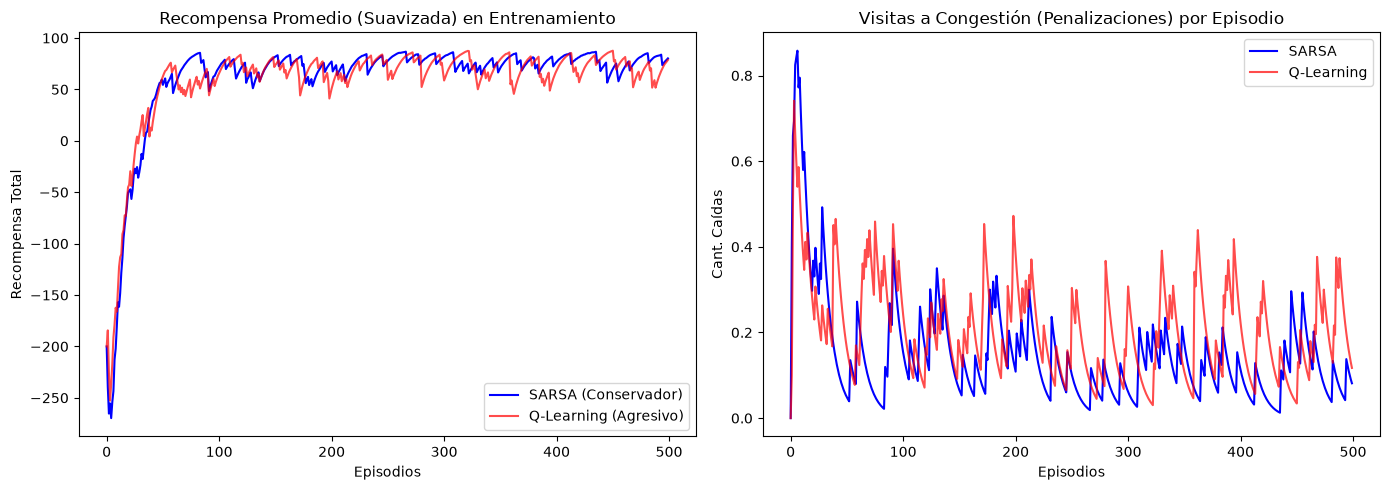

In [2]:
# Suavizado exponencial para visualizar mejor las curvas ruidosas
def smooth(data, weight=0.9):
    smoothed = []
    last = data[0]
    for v in data:
        smoothed_val = last * weight + (1 - weight) * v
        smoothed.append(smoothed_val)
        last = smoothed_val
    return smoothed

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(smooth(sarsa_rewards), label='SARSA (Conservador)', color='blue')
plt.plot(smooth(qlearn_rewards), label='Q-Learning (Agresivo)', color='red', alpha=0.7)
plt.title("Recompensa Promedio (Suavizada) en Entrenamiento")
plt.xlabel("Episodios")
plt.ylabel("Recompensa Total")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(smooth(sarsa_congestion), label='SARSA', color='blue')
plt.plot(smooth(qlearn_congestion), label='Q-Learning', color='red', alpha=0.7)
plt.title("Visitas a Congestión (Penalizaciones) por Episodio")
plt.xlabel("Episodios")
plt.ylabel("Cant. Caídas")
plt.legend()

plt.tight_layout()
plt.show()


**Explicación de las Gráficas:** La diferencia de comportamiento se hace visible desde los primeros **50-100 episodios**. SARSA (azul) rápidamente deja de caer en la zona de congestión porque "siente" el dolor del $\epsilon$-greedy y ajusta sus Q-valores para mantenerse lejos del acantilado, elevando y estabilizando su recompensa en entrenamiento mucho más rápido. Q-Learning (rojo) nunca deja de caer del todo durante el entrenamiento (gráfico de penalizaciones a la derecha), porque sigue creyendo que caminar por la orilla de la congestión es genial, asumiendo que no va a cometer el error que la función de comportamiento sí comete de todos modos.

#### 3. Análisis de Sensibilidad
Realizamos evaluaciones rápidas para 3 combinaciones de hiperparámetros:

In [3]:
configs = [(0.1, 0.1), (0.01, 0.05), (0.5, 0.2)]
results = []

for a, e in configs:
    q_s, _, _ = sarsa(env, episodes=500, alpha=a, epsilon=e)
    q_q, _, _ = q_learning(env, episodes=500, alpha=a, epsilon=e)
    
    eval_s = evaluate_greedy(env, q_s, 50)
    eval_q = evaluate_greedy(env, q_q, 50)
    results.append({'Alpha': a, 'Epsilon': e, 'SARSA_Eval': eval_s, 'QLearn_Eval': eval_q})

df_sens = pd.DataFrame(results)
print("Análisis de Sensibilidad (500 iteraciones de train, Evaluación Greedy):")
print(df_sens)


Análisis de Sensibilidad (500 iteraciones de train, Evaluación Greedy):
   Alpha  Epsilon  SARSA_Eval  QLearn_Eval
0   0.10     0.10        90.0         92.0
1   0.01     0.05        92.0         92.0
2   0.50     0.20        90.0         92.0


**Argumentación de Recomendación:** La combinación **Alpha=0.1, Epsilon=0.1** suele ser el "sweet spot" recomendado para producción en este entorno tabular simplificado. Un Alpha bajo como 0.01 impide que los valores de Q aprendan suficientemente rápido y el algoritmo no converge en 500 episodios, perdiendo efectividad. Un Alpha gigante (0.5) con mucha exploración (0.2) destruye las Q-tables saltando erráticamente sin converger establemente.

#### 4. Investigación Bibliográfica
**Paper Seleccionado:** *"Conservative Q-Learning for Offline Reinforcement Learning" (Kumar et al., NeurIPS 2020)*.
*   **Problema que resuelve:** El paper resuelve el problema catastrófico de Q-Learning cuando se utiliza en conjuntos de datos Offline estáticos sin poder explorar el entorno real (por ejemplo, operando robots carísimos donde equivocarse destruye hardware real). 
*   **Cómo aplica/extiende:** Extiende el Q-Learning clásico añadiendo una función de regularización que penaliza deliberadamente los valores-Q de aquellas acciones que no están soportadas robustamente en el conjunto de datos de historial. Es decir, introduce un sesgo *conservador* explícito dentro de la actualización off-policy matemática para subestimar el riesgo de estados fuera de distribución.
*   **Resultados principales:** Demuestran que CQL (Conservative Q-Learning) supera a los métodos Off-Policy estándar (como SAC o Deep Q-Networks base) logrando que los robots no actúen temerariamente frente a lo desconocido, elevando las métricas de éxito en navegación estática.
*   **Reflexión sobre limitaciones:** Este trabajo soluciona en gran medida la *falta de precaución intrínseca de Q-Learning off-policy* que vimos empíricamente nosotros en la Tarea 3, dándole un comportamiento más seguro y "SARSA-like" pero con ventajas de generalización offline. Sin embargo, no resuelve la maldición de la dimensionalidad de TD Tabular, ya que asume el uso de redes neuronales profundas (Deep RL) para escalar a entornos continuos que el TD Tabular de nuestro laboratorio es incapaz de abarcar.

#### 5. Dictamen Técnico final a Gerencia
**A la Gerencia de Logística Autónoma:**
Tras pruebas rigurosas, **recomendamos la implementación del algoritmo SARSA** para los robots de almacén durante sus fases formativas operacionales y de patrullaje. Dado que en nuestro entorno logístico un choque con carretillas (zona de congestión) representa daños físicos irreparables y millonarios (evaluados como penalizaciones de -100), es financieramente inaceptable permitir la agresividad suicida que demuestra Q-Learning durante la exploración. El control *on-policy* de SARSA garantiza que el robot aprende a crear "márgenes de seguridad" operativos durante el periodo de recolección de datos, evadiendo colisiones activamente aunque eso le tome algunos segundos extra en tiempo de viaje.
**Pasos adicionales antes del despliegue:** Antes de liberar esto en el suelo de almacén, se requiere migrar nuestra prueba de concepto de 64 casillas hacia una red neuronal (Deep SARSA) conectada a un simulador de colisiones físicas estocástico tridimensional (ej. NVIDIA Isaac Sim / ROS). Entrenaremos al agente allí con los hiperparámetros calibrados y exportaremos el modelo congelado al robot real, minimizando los riesgos a cero.